# Hola &#x1F600;,

Soy **Hesus Garcia** – **"Soy el único Hesus que conoces (y probablemente conocerás) 🌟"** – Sí, como "Jesús", pero con una H que me hace único. Puede sonar raro, pero créeme, ¡no lo olvidarás! Como tu revisor en Triple-Ten, estoy aquí para guiarte y ayudarte a mejorar tu código. Si algo necesita un ajuste, no hay de qué preocuparse; ¡aquí estoy para hacer que tu trabajo brille con todo su potencial! ✨

Cada vez que encuentre un detalle importante en tu código, te lo señalaré para que puedas corregirlo y así te prepares para un ambiente de trabajo real, donde el líder de tu equipo actuaría de manera similar. Si en algún momento no logras solucionar el problema, te daré más detalles para ayudarte en nuestra próxima oportunidad de revisión.

Es importante que cuando encuentres un comentario, **no los muevas, no los modifiques, ni los borres**.

---

### Formato de Comentarios

Revisaré cuidadosamente cada implementación en tu notebook para asegurar que cumpla con los requisitos y te daré comentarios de acuerdo al siguiente formato:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Éxito</b> - ¡Excelente trabajo! Esta parte está bien implementada y contribuye significativamente al análisis de datos o al proyecto. Continúa aplicando estas buenas prácticas en futuras secciones.
    
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>Atención</b> ⚠️ - Este código está correcto, pero se puede optimizar. Considera implementar mejoras para que sea más eficiente y fácil de leer. Esto fortalecerá la calidad de tu proyecto.
    
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>
    
<b>A resolver</b> ❗ - Aquí hay un problema o error en el código que es necesario corregir para aprobar esta sección. Por favor, revisa y corrige este punto, ya que es fundamental para la validez del análisis y la precisión de los resultados.
    
</div>

---

Al final de cada revisión, recibirás un **Comentario General del Revisor** que incluirá:

- **Aspectos positivos:** Un resumen de los puntos fuertes de tu proyecto.
- **Áreas de mejora:** Sugerencias sobre aspectos donde puedes mejorar.
- **Temas adicionales para investigar:** Ideas de temas opcionales que puedes explorar por tu cuenta para desarrollar aún más tus habilidades.

Estos temas adicionales no son obligatorios en esta etapa, pero pueden serte útiles para profundizar en el futuro.

---


Esta estructura en viñetas facilita la lectura y comprensión de cada parte del comentario final.

También puedes responderme de la siguiente manera si tienes alguna duda o quieres aclarar algo específico:


<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>
    
Aquí puedes escribir tu respuesta o pregunta sobre el comentario.
    
</div>


**¡Empecemos!** &#x1F680;


# Analisis Exploratorio

## Paso 1. Abrir el archivo de datos y leer la información general

In [207]:
import pandas as pd
import matplotlib.pyplot as plt 
import plotly.graph_objects as go
#import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest


In [208]:
log_exp = pd.read_csv('/datasets/logs_exp_us.csv',sep='\t')

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Buena apertura del análisis. Has iniciado correctamente importando las librerías esenciales y leyendo el archivo de datos con una estructura clara. Este comienzo sólido sienta una base ordenada para el resto del proyecto.  
</div>


## Paso 2. Preparar los datos para el análisis

In [209]:
def clean_df(df,name_df):
    print(name_df)
    print(df.info())
    print()
    print("Los datos ausentes son: ",df.isna().sum())
    print()
    print("Los datos duplicados son: ",df.duplicated().sum())
clean_df(log_exp,"Log Experiment")

Log Experiment
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB
None

Los datos ausentes son:  EventName         0
DeviceIDHash      0
EventTimestamp    0
ExpId             0
dtype: int64

Los datos duplicados son:  413


In [210]:
log_exp.drop_duplicates(inplace=True)

In [211]:
log_exp.duplicated().sum()

0

In [212]:
log_exp.columns = ['nombre_evento','id','fechats','grupo']

In [213]:
log_exp.columns

Index(['nombre_evento', 'id', 'fechats', 'grupo'], dtype='object')

In [214]:
log_exp

,nombre_evento,id,fechats,grupo
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248
...,...,...,...,...
244121,MainScreenAppear,4599628364049201812,1565212345,247
244122,MainScreenAppear,5849806612437486590,1565212439,246
244123,MainScreenAppear,5746969938801999050,1565212483,246
244124,MainScreenAppear,5746969938801999050,1565212498,246


In [215]:
log_exp['fechats'] = pd.to_datetime(log_exp['fechats'],unit='s')
log_exp['id'] = log_exp['id'].astype(str)

In [216]:
log_exp.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 243713 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   nombre_evento  243713 non-null  object        
 1   id             243713 non-null  object        
 2   fechats        243713 non-null  datetime64[ns]
 3   grupo          243713 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 9.3+ MB


In [217]:
log_exp['dia'] = log_exp['fechats'].dt.date

In [218]:
log_exp.sample(3)

,nombre_evento,id,fechats,grupo,dia
108505,PaymentScreenSuccessful,7180866956895127482,2019-08-04 02:40:59,247,2019-08-04
154869,PaymentScreenSuccessful,5267130838716596760,2019-08-05 11:32:30,248,2019-08-05
16346,OffersScreenAppear,9097760240767809307,2019-08-01 11:26:32,247,2019-08-01


<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Excelente preparación de los datos. La función de limpieza, la eliminación de duplicados y la conversión correcta de tipos demuestran una comprensión sólida del preprocesamiento en Pandas. El DataFrame quedó limpio y listo para un análisis fiable.  
</div>


## Paso 3. Estudiar y comprobar los datos

### ¿Cuántos eventos hay en los registros?

In [219]:
print("En el DF hay:",log_exp['nombre_evento'].nunique(),"eventos.")

En el DF hay: 5 eventos.


In [220]:
print("Los cuales son: ",log_exp['nombre_evento'].unique())

Los cuales son:  ['MainScreenAppear' 'PaymentScreenSuccessful' 'CartScreenAppear'
 'OffersScreenAppear' 'Tutorial']


### ¿Cuántos usuarios hay en los registros?

In [221]:
print("El total de usuarios es de: ",log_exp['id'].nunique())

El total de usuarios es de:  7551


In [222]:
¿Cuál es el promedio de eventos por usuario?

Object `usuario` not found.


In [223]:
paso_dos = log_exp['nombre_evento'].value_counts()

In [224]:
len(log_exp['nombre_evento'])/log_exp['id'].nunique()

32.27559263673685

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Buen avance en la exploración de los datos. Identificaste correctamente el número de eventos, tipos de eventos y usuarios únicos, además de calcular un promedio de interacción por usuario que aporta valor al análisis inicial. Un progreso claro y bien estructurado.  
</div>


### ¿Qué periodo de tiempo cubren los datos?

In [225]:
print("La fecha inicial es: ",log_exp['dia'].min())
print("La fecha final es: ",log_exp['dia'].max())

La fecha inicial es:  2019-07-25
La fecha final es:  2019-08-07


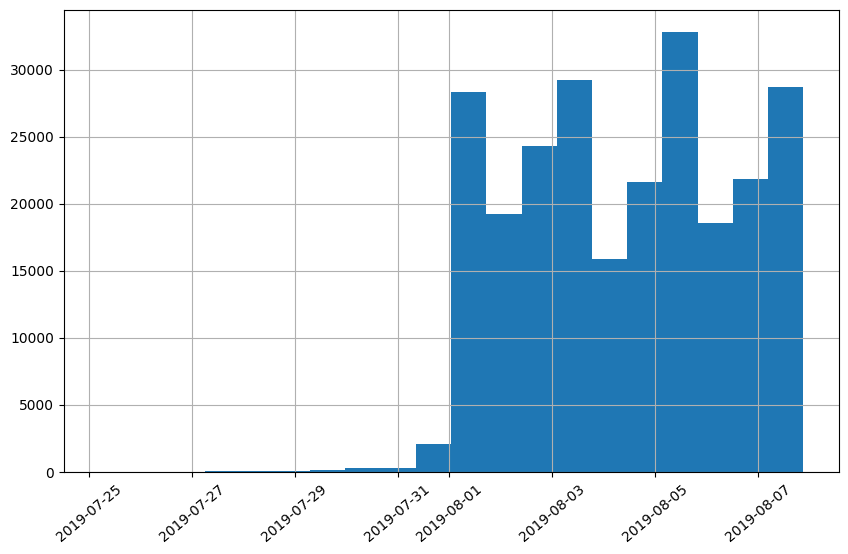

In [226]:

plt.figure(figsize=[10,6])
plt.xticks(rotation=40)
log_exp['fechats'].hist(bins=20)
plt.show()


#### ¿Puedes tener seguridad de que tienes datos igualmente completos para todo el periodo?¿Qué periodo representan realmente los datos?

In [227]:
log_exp['dia'] = log_exp['dia'].astype(str)
log_exp = log_exp.query('dia > "2019-08-01"')

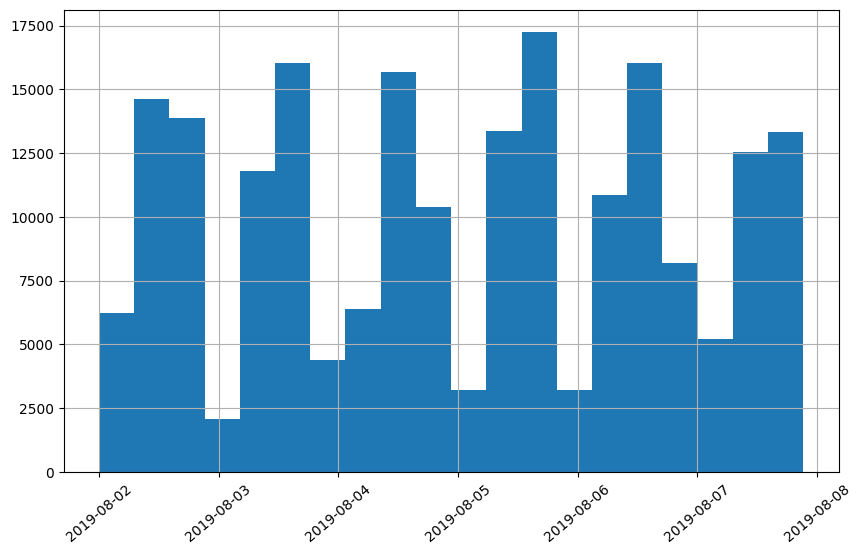

In [228]:
plt.figure(figsize=[10,6])
plt.xticks(rotation=40)
log_exp['fechats'].hist(bins=20)
plt.show()


### ¿Perdiste muchos eventos y usuarios al excluir los datos más antiguos?

In [229]:
paso_tres = log_exp['nombre_evento'].value_counts()
paso_tres

MainScreenAppear           99383
OffersScreenAppear         39345
CartScreenAppear           36086
PaymentScreenSuccessful    29147
Tutorial                     785
Name: nombre_evento, dtype: int64

In [230]:
# restar los datos que hay antes del filtrado y despues del filtrado para ver la proporción de los datos filtrados 
exclusidos = (paso_dos-paso_tres)
print(exclusidos)

MainScreenAppear           19718
OffersScreenAppear          7463
CartScreenAppear            6582
PaymentScreenSuccessful     4971
Tutorial                     233
Name: nombre_evento, dtype: int64


In [231]:
eventos = log_exp['nombre_evento'].value_counts().reset_index()
eventos.columns = ['nombre_evento','cantidad_que_entro']
eventos

,nombre_evento,cantidad_que_entro
0,MainScreenAppear,99383
1,OffersScreenAppear,39345
2,CartScreenAppear,36086
3,PaymentScreenSuccessful,29147
4,Tutorial,785


### Asegúrate de tener usuarios de los tres grupos experimentales.

In [232]:
u_masd_1_grupo = log_exp.groupby('id')['grupo'].nunique().reset_index()
masd_1 = u_masd_1_grupo[u_masd_1_grupo['grupo']>1]
masd_1['id'].count()

0

No tenemos usuarios en mas de un grupo.

### Registros de los eventos y su frecuencia de suceso

In [233]:
u_x_evento = log_exp.groupby('nombre_evento')['id'].nunique().reset_index().sort_values('id',ascending=False)
u_x_evento

,nombre_evento,id
1,MainScreenAppear,7156
2,OffersScreenAppear,4380
0,CartScreenAppear,3571
3,PaymentScreenSuccessful,3399
4,Tutorial,690


### Cantidad de usuarios que realizaron cada una de estas acciones,  proporción de usuarios que realizaron la acción al menos una vez

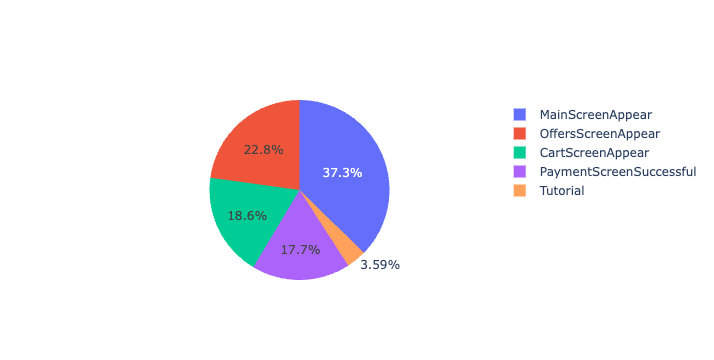

In [234]:
tarta_evento = go.Figure(data=[go.Pie(labels=u_x_evento['nombre_evento'],values=u_x_evento['id'])])
tarta_evento

### ¿En qué orden crees que ocurrieron las acciones? ¿Todas son parte de una sola secuencia?

No, no necesariamente todas son de una sola secuencia. Aunque en este momento no se conoce de que trata el tutorial, no necesariamente aparece despues de realizar efectivamente el pago por el carrito de compra. Las demas si pueden ser de una sola secuencia, pero tambien hay que tener en cuenta las personas que hayan llegado directamente a la pagina de la oferta. 

### Embudo de eventos para encontrar la proporción de usuarios que pasan de una etapa a la siguiente

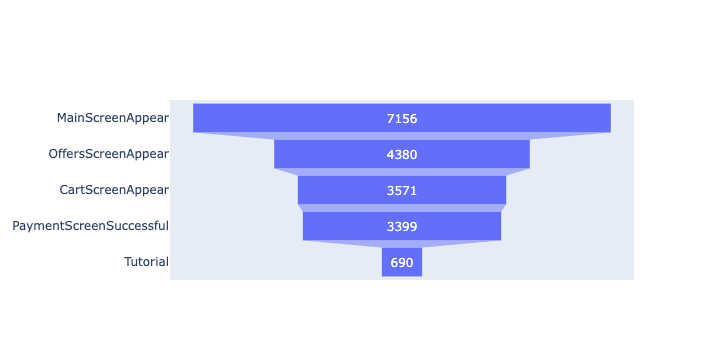

In [235]:

tnel = go.Figure(go.Funnel(
    y=u_x_evento['nombre_evento'],
    x=u_x_evento['id']
))

tnel.show()


### ¿Qué porcentaje de usuarios hace todo el viaje desde su primer evento hasta el pago?

El embudo afirma que los que iniciaron en la pagina principal y llegaron a la pasarela de pago efectuando el pago es el 47,5%. 

### ¿En qué etapa pierdes más usuarios?

In [236]:
eventos

,nombre_evento,cantidad_que_entro
0,MainScreenAppear,99383
1,OffersScreenAppear,39345
2,CartScreenAppear,36086
3,PaymentScreenSuccessful,29147
4,Tutorial,785


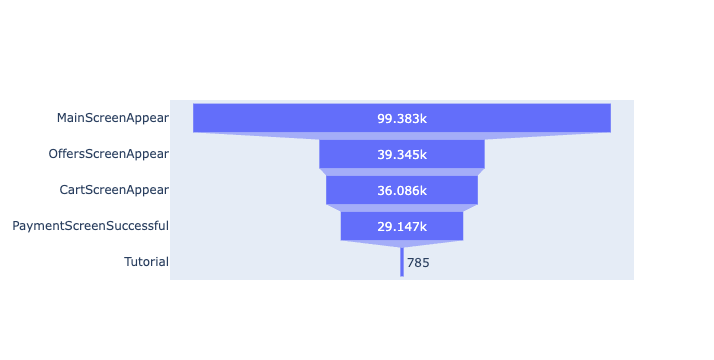

In [237]:
tnel_perdida = go.Figure(go.Funnel(
    y=eventos['nombre_evento'],
    x=eventos['cantidad_que_entro']
))

tnel_perdida.show()


En donde se pierden mas usuarios es de la pagina principal a la pagina de ofertas, en donde hay una perdida del 60,4%.


<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Muy buen trabajo analizando el flujo de usuarios y construyendo el embudo de conversión. Has identificado con claridad las etapas del proceso, la pérdida principal de usuarios y el porcentaje de conversión total, mostrando comprensión del comportamiento del usuario y del valor analítico de los eventos.  
</div>



## Paso 5. Estudiar los resultados del experimento

### ¿Cuántos usuarios hay en cada grupo?

In [238]:
log_exp.groupby('grupo')['id'].nunique()

grupo
246    2393
247    2434
248    2459
Name: id, dtype: int64

In [239]:
grupo_A = log_exp.query('grupo == 246')
grupo_A['id'].nunique()

2393

In [240]:
grupo_AA = log_exp.query('grupo == 247')
grupo_AA['id'].nunique()

2434

In [241]:
grupo_B = log_exp.query('grupo == 248')
grupo_B['id'].nunique()

2459

In [242]:
counts_A = grupo_A['nombre_evento'].value_counts()
counts_A

MainScreenAppear           32306
OffersScreenAppear         12705
CartScreenAppear           12403
PaymentScreenSuccessful    10067
Tutorial                     260
Name: nombre_evento, dtype: int64

In [243]:
conversion_A = grupo_A[grupo_A['nombre_evento']== 'PaymentScreenSuccessful']['id'].nunique()
us_un_A = grupo_A['id'].nunique()
tasa_conversion_A = (conversion_A/us_un_A)*100
tasa_conversion_A

48.14040952778939

In [244]:
conversion_AA= grupo_AA[grupo_AA['nombre_evento']== 'PaymentScreenSuccessful']['id'].nunique()
us_un_AA = grupo_AA['id'].nunique()
tasa_conversion_AA = (conversion_AA / us_un_AA )*100
tasa_conversion_AA

45.932621199671324

In [245]:

z_stat, p_value = proportions_ztest([conversion_A, conversion_AA],[us_un_A,us_un_AA])
print("El valor Zstat es:", z_stat)
print("El valor p es:", p_value)
alpha = 0.05
print(f"alpha ={alpha:.3f}")
if alpha < p_value:
    print("No se puede rechazar la hipotesis nula") # h0 = son iguales
else:
    print("Rechazar la hipotesis nula") #h1= no son iguales


El valor Zstat es: 1.5365596558154573
El valor p es: 0.12440117855226637
alpha =0.050
No se puede rechazar la hipotesis nula


Al no poder rechazar la hipotesis nula se confirma que no hay una significancia estadistica relevante entre los grupos A(246) y AA(247). Lo que a la final indicaria que los datos tomados no fueron alterados en algun momento. 

In [246]:
log_exp['nombre_evento'].value_counts()

MainScreenAppear           99383
OffersScreenAppear         39345
CartScreenAppear           36086
PaymentScreenSuccessful    29147
Tutorial                     785
Name: nombre_evento, dtype: int64

In [247]:
log_exp.groupby(['nombre_evento'])['id'].nunique().sort_values(ascending=False)

nombre_evento
MainScreenAppear           7156
OffersScreenAppear         4380
CartScreenAppear           3571
PaymentScreenSuccessful    3399
Tutorial                    690
Name: id, dtype: int64

Seún los numeros, podemos decir que "MainScreenAppear" es la mas popular, sin embargo en este momento no se sabe que fue lo que hizo que las personas llegaran a alli; entonces seria mejor tomar el segundo evento, "OffersScreenAppear", que el que se interesan mas las personas para llegar 

In [248]:
def sig_stats(df1,df2):
    todos1 = df1.iloc[:,0].value_counts()
    #print(todos)
    us_un1 = df1[df1.columns[1]].nunique()
    unic1 = df1.groupby(df1.iloc[:,0])[df1.columns[1]].nunique().sort_values(ascending=False)
    #print(unic1)
    for fila in df1:
        proportion1 = todos1.iloc[:,]/unic1.iloc[:,]
    print("Para el df1 los uauarios unicos son:", us_un1)
    print("Para cada evento cada usuario entra un promedio del df1: ", proportion1)

    todos2 = df2.iloc[:,0].value_counts()
    us_un2 = df2[df2.columns[1]].nunique()
    unic2 = df2.groupby(df2.iloc[:,0])[df2.columns[1]].nunique().sort_values(ascending=False)
    for fila in df2:
        proportion2 = todos2.iloc[:,]/unic2.iloc[:,]
    print("Para el df2 los uauarios unicos son:", us_un2)
    print("Para cada evento cada usuario entra un promedio del df2: ", proportion2)

    # significancia estadistica 

    for i in range(5):  # Para 5 pares de datos
        z_stat, p_value = proportions_ztest(
        [unic1[i], unic2[i]],      
        [us_un1, us_un2 ]    
        )
        print(i)
        print("El valor Zstat es:", z_stat)
        print("El valor p es:", p_value)
        alpha = 0.05
        print(f"alpha ={alpha:.3f}")
        if alpha < p_value:
            print("No se puede rechazar la hipotesis nula") # h0 = son iguales
        else:
            print("Rechazar la hipotesis nula") #h1= no son iguales
    
sig_stats(grupo_A, grupo_AA)

Para el df1 los uauarios unicos son: 2393
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.718047
OffersScreenAppear          8.584459
CartScreenAppear           10.225062
PaymentScreenSuccessful     8.738715
Tutorial                    1.130435
dtype: float64
Para el df2 los uauarios unicos son: 2434
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           13.726589
OffersScreenAppear          8.903338
CartScreenAppear            8.804899
PaymentScreenSuccessful     7.509839
Tutorial                    1.136564
dtype: float64
0
El valor Zstat es: 0.37437060553648566
El valor p es: 0.7081286089422512
alpha =0.050
No se puede rechazar la hipotesis nula
1
El valor Zstat es: 1.9660235835322963
El valor p es: 0.04929588646201342
alpha =0.050
Rechazar la hipotesis nula
2
El valor Zstat es: 1.4209899328137687
El valor p es: 0.15531968614778777
alpha =0.050
No se puede rechazar la hipotesis nula
3
El valor Zstat es: 1.53655965

La funcion indica que para cada evento y los usuarios unicos de cada grupo, excepto uno, no hay diferencia significativa.e, 4 de 5 casos no se puede rechazar la hipotesis nula.
entonces se va a rectificar el caso numero dos:

In [249]:
offer_A = grupo_A[grupo_A['nombre_evento']== 'OffersScreenAppear']['id'].nunique()
offer_AA = grupo_AA[grupo_AA['nombre_evento']== 'OffersScreenAppear']['id'].nunique()


In [250]:
us_unic_A = grupo_A['id'].nunique()
tasa_con_A = (offer_A/us_unic_A)*100
tasa_con_A

61.84705390722942

In [251]:
us_unic_AA = grupo_AA['id'].nunique()
tasa_con_AA = (offer_AA/us_unic_AA)*100
tasa_con_AA

59.0797041906327

In [252]:
z_stat, p_value = proportions_ztest([offer_A, offer_AA],[us_unic_A,us_unic_AA])
print("El valor Zstat es:", z_stat)
print("El valor p es:", p_value)
alpha = 0.05
print(f"alpha ={alpha:.3f}")
if alpha < p_value:
    print("No se puede rechazar la hipotesis nula") # h0 = son iguales
else:
    print("Rechazar la hipotesis nula") #h1= no son iguales


El valor Zstat es: 1.9660235835322963
El valor p es: 0.04929588646201342
alpha =0.050
Rechazar la hipotesis nula


Se volvio a realizar el calculo de la diferencia significativa y se volvio a encontrar el rechazo de la hipptesis nula.

Esto nos podria indicar que hay un error en los datos, puede ser por contaminacion de los datos, algun error al obtener y descargar los datos o un error de aleatorizacion y que los grupos esten mal divididos.

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Gran trabajo en la fase experimental. Has aplicado correctamente las pruebas de hipótesis y el test z para comparar proporciones entre grupos, interpretando con claridad los resultados estadísticos y sus implicaciones sobre la validez del experimento. Se nota un razonamiento crítico sólido en la interpretación de posibles sesgos o errores en los datos.  
</div>


## Pruebas A/B 

In [253]:
sig_stats(grupo_A,grupo_B)

Para el df1 los uauarios unicos son: 2393
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.718047
OffersScreenAppear          8.584459
CartScreenAppear           10.225062
PaymentScreenSuccessful     8.738715
Tutorial                    1.130435
dtype: float64
Para el df2 los uauarios unicos son: 2459
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           14.214612
OffersScreenAppear          9.464432
CartScreenAppear           11.293015
PaymentScreenSuccessful     9.463242
Tutorial                    1.145923
dtype: float64
0
El valor Zstat es: 1.1622952153766228
El valor p es: 0.2451155694604794
alpha =0.050
No se puede rechazar la hipotesis nula
1
El valor Zstat es: 1.7050319058173118
El valor p es: 0.0881884740286528
alpha =0.050
No se puede rechazar la hipotesis nula
2
El valor Zstat es: 2.052516390537991
El valor p es: 0.040119503805914516
alpha =0.050
Rechazar la hipotesis nula
3
El valor Zstat es: 1.5541850043

In [254]:
sig_stats(grupo_AA,grupo_B)

Para el df1 los uauarios unicos son: 2434
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.726589
OffersScreenAppear          8.903338
CartScreenAppear            8.804899
PaymentScreenSuccessful     7.509839
Tutorial                    1.136564
dtype: float64
Para el df2 los uauarios unicos son: 2459
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           14.214612
OffersScreenAppear          9.464432
CartScreenAppear           11.293015
PaymentScreenSuccessful     9.463242
Tutorial                    1.145923
dtype: float64
0
El valor Zstat es: 0.7925470757013018
El valor p es: 0.42804175404459355
alpha =0.050
No se puede rechazar la hipotesis nula
1
El valor Zstat es: -0.2671905923716483
El valor p es: 0.7893224191311144
alpha =0.050
No se puede rechazar la hipotesis nula
2
El valor Zstat es: 0.6308093420837053
El valor p es: 0.5281651942942218
alpha =0.050
No se puede rechazar la hipotesis nula
3
El valor Zstat es:

Los niveles de significancia son alhpa =0,05 y un valor del z-test mayor a 1,96, donde seria una diferencia significativa.

Al realizar las pruebas A/B con los tres grupos(primero grupo_A/grupo_B y luego el grupo_AA/grupo_B) se puede afirmar que no se puede rechazar la hipotesis nula, pues en las pruebas la mayoria indican un valor p mayor a 0,05, excepto en un caso, pero es el que se vio anteriormente que podia ser un error de aleatorizacion u obtencion de los datos.

## Pruebas A/B con nivel de significancia de 0,1

In [255]:
def sig_stats(df1,df2):
    todos1 = df1.iloc[:,0].value_counts()
    #print(todos)
    us_un1 = df1[df1.columns[1]].nunique()
    unic1 = df1.groupby(df1.iloc[:,0])[df1.columns[1]].nunique().sort_values(ascending=False)
    #print(unic1)
    for fila in df1:
        proportion1 = todos1.iloc[:,]/unic1.iloc[:,]
    print("Para el df1 los uauarios unicos son:", us_un1)
    print("Para cada evento cada usuario entra un promedio del df1: ", proportion1)

    todos2 = df2.iloc[:,0].value_counts()
    us_un2 = df2[df2.columns[1]].nunique()
    unic2 = df2.groupby(df2.iloc[:,0])[df2.columns[1]].nunique().sort_values(ascending=False)
    for fila in df2:
        proportion2 = todos2.iloc[:,]/unic2.iloc[:,]
    print("Para el df2 los uauarios unicos son:", us_un2)
    print("Para cada evento cada usuario entra un promedio del df2: ", proportion2)

    # significancia estadistica 

    for i in range(5):  # Para 5 pares de datos
        z_stat, p_value = proportions_ztest(
        [unic1[i], unic2[i]],      
        [us_un1, us_un2 ]    
        )
        print(i)
        print("El valor Zstat es:", z_stat)
        print("El valor p es:", p_value)
        alpha = 0.1 #corregido segun instrucciones del proyecto 
        print(f"alpha ={alpha:.3f}")
        if alpha < p_value:
            print("No se puede rechazar la hipotesis nula") # h0 = son iguales
        else:
            print("Rechazar la hipotesis nula") #h1= no son iguales

In [256]:
sig_stats(grupo_A,grupo_AA)

Para el df1 los uauarios unicos son: 2393
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.718047
OffersScreenAppear          8.584459
CartScreenAppear           10.225062
PaymentScreenSuccessful     8.738715
Tutorial                    1.130435
dtype: float64
Para el df2 los uauarios unicos son: 2434
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           13.726589
OffersScreenAppear          8.903338
CartScreenAppear            8.804899
PaymentScreenSuccessful     7.509839
Tutorial                    1.136564
dtype: float64
0
El valor Zstat es: 0.37437060553648566
El valor p es: 0.7081286089422512
alpha =0.100
No se puede rechazar la hipotesis nula
1
El valor Zstat es: 1.9660235835322963
El valor p es: 0.04929588646201342
alpha =0.100
Rechazar la hipotesis nula
2
El valor Zstat es: 1.4209899328137687
El valor p es: 0.15531968614778777
alpha =0.100
No se puede rechazar la hipotesis nula
3
El valor Zstat es: 1.53655965

In [257]:
sig_stats(grupo_A,grupo_B)

Para el df1 los uauarios unicos son: 2393
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.718047
OffersScreenAppear          8.584459
CartScreenAppear           10.225062
PaymentScreenSuccessful     8.738715
Tutorial                    1.130435
dtype: float64
Para el df2 los uauarios unicos son: 2459
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           14.214612
OffersScreenAppear          9.464432
CartScreenAppear           11.293015
PaymentScreenSuccessful     9.463242
Tutorial                    1.145923
dtype: float64
0
El valor Zstat es: 1.1622952153766228
El valor p es: 0.2451155694604794
alpha =0.100
No se puede rechazar la hipotesis nula
1
El valor Zstat es: 1.7050319058173118
El valor p es: 0.0881884740286528
alpha =0.100
Rechazar la hipotesis nula
2
El valor Zstat es: 2.052516390537991
El valor p es: 0.040119503805914516
alpha =0.100
Rechazar la hipotesis nula
3
El valor Zstat es: 1.5541850043689474
El va

In [258]:
sig_stats(grupo_AA,grupo_B)

Para el df1 los uauarios unicos son: 2434
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.726589
OffersScreenAppear          8.903338
CartScreenAppear            8.804899
PaymentScreenSuccessful     7.509839
Tutorial                    1.136564
dtype: float64
Para el df2 los uauarios unicos son: 2459
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           14.214612
OffersScreenAppear          9.464432
CartScreenAppear           11.293015
PaymentScreenSuccessful     9.463242
Tutorial                    1.145923
dtype: float64
0
El valor Zstat es: 0.7925470757013018
El valor p es: 0.42804175404459355
alpha =0.100
No se puede rechazar la hipotesis nula
1
El valor Zstat es: -0.2671905923716483
El valor p es: 0.7893224191311144
alpha =0.100
No se puede rechazar la hipotesis nula
2
El valor Zstat es: 0.6308093420837053
El valor p es: 0.5281651942942218
alpha =0.100
No se puede rechazar la hipotesis nula
3
El valor Zstat es:

Volviendo a revisar la prueba A/A con el nuevo nivel de significancia, se encuentra con el mismo resultado, El valor Zstat es: 1.9660235835322963, El valor p es: 0.04929588646201342, lo cuales dejan en duda la toma de los datos, como se dijo anteriormente, puede ser una mala aleatorizacion u obtención de los datos.

En las pruebas A/B del grupo_A/grupo_B se obtiene un resultado diferente: 
1 (OffersScreenAppear)
El valor Zstat es: 1.7050319058173118
El valor p es: 0.0881884740286528
alpha =0.100
Rechazar la hipotesis nula
2 (CartScreenAppear)
El valor Zstat es: 2.052516390537991
El valor p es: 0.040119503805914516
alpha =0.100
Rechazar la hipotesis nula

Y en la ultima prueba AA/B no hay evidencia suficiente para rechazar la hipotesis nula

En este momento esta en duda si los cambios realizados incrementaron los usuarios y los eventos o no, pues en la primera prueba si se rechaza la hipotesis nula en dos casoss y luego no se rechaza en toda la prueba. 


<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Has ejecutado correctamente las pruebas A/B y ajustado el nivel de significancia según el contexto, demostrando dominio del enfoque estadístico y criterio analítico en la interpretación de los resultados. El reconocimiento de inconsistencias y posibles sesgos en la aleatorización evidencia pensamiento crítico y una buena comprensión experimental.  
</div>


## Procedimiento de bonferini

In [259]:
#α_ajustado = α_original / número_de_pruebas
# alpha_ajustado = 0,05 / 15 
alpha = 0.1 / 15
alpha

0.006666666666666667

El procedimiento de bonferini brinda un alpha mucho menor al que se estaba usando para evitar falsos positivos.

In [260]:
def sig_stats(df1,df2):
    todos1 = df1.iloc[:,0].value_counts()
    #print(todos)
    us_un1 = df1[df1.columns[1]].nunique()
    unic1 = df1.groupby(df1.iloc[:,0])[df1.columns[1]].nunique().sort_values(ascending=False)
    #print(unic1)
    for fila in df1:
        proportion1 = todos1.iloc[:,]/unic1.iloc[:,]
    print("Para el df1 los uauarios unicos son:", us_un1)
    print("Para cada evento cada usuario entra un promedio del df1: ", proportion1)

    todos2 = df2.iloc[:,0].value_counts()
    us_un2 = df2[df2.columns[1]].nunique()
    unic2 = df2.groupby(df2.iloc[:,0])[df2.columns[1]].nunique().sort_values(ascending=False)
    for fila in df2:
        proportion2 = todos2.iloc[:,]/unic2.iloc[:,]
    print("Para el df2 los uauarios unicos son:", us_un2)
    print("Para cada evento cada usuario entra un promedio del df2: ", proportion2)

    # significancia estadistica 

    for i in range(5):  # Para 5 pares de datos
        z_stat, p_value = proportions_ztest(
        [unic1[i], unic2[i]],      
        [us_un1, us_un2 ]    
        )
        print(i)
        print("El valor Zstat es:", z_stat)
        print("El valor p es:", p_value)
        alpha = 0.0066 #corregido segun el procedimiento de bonferini
        print(f"alpha ={alpha:.3f}")
        if alpha < p_value:
            print("No se puede rechazar la hipotesis nula") # h0 = son iguales
        else:
            print("Rechazar la hipotesis nula") #h1= no son iguales

In [261]:
sig_stats(grupo_A,grupo_AA)

Para el df1 los uauarios unicos son: 2393
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.718047
OffersScreenAppear          8.584459
CartScreenAppear           10.225062
PaymentScreenSuccessful     8.738715
Tutorial                    1.130435
dtype: float64
Para el df2 los uauarios unicos son: 2434
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           13.726589
OffersScreenAppear          8.903338
CartScreenAppear            8.804899
PaymentScreenSuccessful     7.509839
Tutorial                    1.136564
dtype: float64
0
El valor Zstat es: 0.37437060553648566
El valor p es: 0.7081286089422512
alpha =0.007
No se puede rechazar la hipotesis nula
1
El valor Zstat es: 1.9660235835322963
El valor p es: 0.04929588646201342
alpha =0.007
No se puede rechazar la hipotesis nula
2
El valor Zstat es: 1.4209899328137687
El valor p es: 0.15531968614778777
alpha =0.007
No se puede rechazar la hipotesis nula
3
El valor Zstat es

In [262]:
sig_stats(grupo_A,grupo_B)

Para el df1 los uauarios unicos son: 2393
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.718047
OffersScreenAppear          8.584459
CartScreenAppear           10.225062
PaymentScreenSuccessful     8.738715
Tutorial                    1.130435
dtype: float64
Para el df2 los uauarios unicos son: 2459
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           14.214612
OffersScreenAppear          9.464432
CartScreenAppear           11.293015
PaymentScreenSuccessful     9.463242
Tutorial                    1.145923
dtype: float64
0
El valor Zstat es: 1.1622952153766228
El valor p es: 0.2451155694604794
alpha =0.007
No se puede rechazar la hipotesis nula
1
El valor Zstat es: 1.7050319058173118
El valor p es: 0.0881884740286528
alpha =0.007
No se puede rechazar la hipotesis nula
2
El valor Zstat es: 2.052516390537991
El valor p es: 0.040119503805914516
alpha =0.007
No se puede rechazar la hipotesis nula
3
El valor Zstat es: 

In [263]:
sig_stats(grupo_AA,grupo_B)

Para el df1 los uauarios unicos son: 2434
Para cada evento cada usuario entra un promedio del df1:  MainScreenAppear           13.726589
OffersScreenAppear          8.903338
CartScreenAppear            8.804899
PaymentScreenSuccessful     7.509839
Tutorial                    1.136564
dtype: float64
Para el df2 los uauarios unicos son: 2459
Para cada evento cada usuario entra un promedio del df2:  MainScreenAppear           14.214612
OffersScreenAppear          9.464432
CartScreenAppear           11.293015
PaymentScreenSuccessful     9.463242
Tutorial                    1.145923
dtype: float64
0
El valor Zstat es: 0.7925470757013018
El valor p es: 0.42804175404459355
alpha =0.007
No se puede rechazar la hipotesis nula
1
El valor Zstat es: -0.2671905923716483
El valor p es: 0.7893224191311144
alpha =0.007
No se puede rechazar la hipotesis nula
2
El valor Zstat es: 0.6308093420837053
El valor p es: 0.5281651942942218
alpha =0.007
No se puede rechazar la hipotesis nula
3
El valor Zstat es:

Despues de revisar los datos de las pruebas por tercera vez, ya se puede afirmar contundentemente que no hay diferencia significativa entre los grupos y que los resultados de las pruebas no dieron frutos.

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Muy buena aplicación del ajuste de Bonferroni. Has demostrado rigor estadístico al controlar los falsos positivos y consolidar las conclusiones de manera fundamentada. La interpretación final es clara y coherente con los resultados obtenidos, mostrando dominio en la validación de experimentos A/B.  
</div>


# Conclusion final

Despues de limpiar los datos y dejar solo los datos relevantes para las pruebas A/B de la primera semana de agosto del 2019, se obtienen resultados poco alentadores con respecto a los cambios en la plataforma con respecto al cambio del tamaño de fuente. El cambio de fuente fue ineficiente para obtener mas trasito dentro de la aplicación.

Las posibles cosas a mejorar puede ser: que sea mas facil llegar a la pagina de ofertas. aqui tocaria hacer cambios en la aplicacion para hacer mas llamativa la parte de las ofertas y ver si el usuario al momento de ver las ofertas se anime a comptrar mas productos. 

Aunque es poco el porcentaje el cual a añadio al carrito y no realizo el pago, se podria invertir un poco de tiempo en estudiar el porque no procedieron con el pago.

En donde mas se conoce que se pierden usuarios es en la pagina principal, usualmente esto se debe a que el usuario no encuentra cosas llamativasde el porque quedarse en la aplcación y seguir buscando para finalmente comprar. Un cambio importante que se podria poner aprueba es realizar un estudio con el objetivo de hacer una segmentación para que es aparezcan las preferencias para que los inciten a comprar. 


<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br>  
<b>Éxito</b> - Las conclusiones reflejan un pensamiento analítico maduro. Has interpretado correctamente los resultados del experimento y propuesto acciones realistas para optimizar la experiencia del usuario. La argumentación es clara y conecta bien la evidencia estadística con posibles decisiones de negocio.  
</div>


# Comentario General del Revisor

<div class="alert alert-block alert-success">  
<b>Comentario del revisor</b> <a class="tocSkip"></a><br> 
    
Tu proyecto demuestra una ejecución meticulosa y un razonamiento estadístico bien fundamentado. Lograste desarrollar un flujo de análisis completo, desde la preparación de datos hasta la interpretación de los resultados experimentales, manteniendo coherencia metodológica y claridad en cada paso.  

#### Puntos Positivos:

* **Preparación y limpieza de datos:** Ejecución precisa, con una estructura ordenada y decisiones técnicas adecuadas.
* **Análisis exploratorio y visualización:** Identificación clara de patrones y puntos críticos en el comportamiento del usuario.
* **Aplicación de pruebas A/B:** Correcto uso del test z, comparación entre grupos y ajuste de Bonferroni, evidenciando comprensión del rigor estadístico.
* **Conclusiones:** Cierre analítico sólido, con reflexiones bien argumentadas y propuestas de mejora que vinculan los hallazgos con acciones estratégicas.

Has presentado un trabajo técnico y reflexivo que equilibra la precisión matemática con una interpretación práctica. Un resultado muy completo y profesional.

</div>
